In [1]:
import torch

In [2]:
class GaussianProcess(torch.nn.Module):
    def __init__(self, X, Y, kernel_func,  lengthscale_init=1.0, signal_var_init= 1.0, noise_var_init=0.001):
        super().__init__()
        self.X = X
        self.Y = Y
        self.kernel_func = kernel_func
        self.lengthscale = torch.nn.Parameter(torch.tensor(lengthscale_init))
        self.noise_var = torch.nn.Parameter(torch.tensor(noise_var_init))
        self.signal_var = torch.nn.Parameter(torch.tensor(signal_var_init))

    def forward(self, X_test=None):
        K = self.kernel_func(self.X, self.X, self.lengthscale, self.signal_var)
        K = K + torch.eye(K.size(0)) * self.noise_var
  
        if X_test is not None:
            K_star = self.kernel_func(self.X, X_test, self.lengthscale, self.signal_var)
            inv_K = torch.inverse(K)
            mean = torch.matmul(K_star.T, torch.matmul(inv_K, self.Y))
            cov = self.kernel_func(X_test, X_test, self.lengthscale, self.signal_var) - torch.matmul(K_star.T, torch.matmul(inv_K, K_star))
            return mean, cov
        else:
            return K

In [3]:
def squared_exponential_kernel(X, Y, lengthscale, signal_var):
    squared_dist = torch.sum(torch.square(X[:, None, :] - Y[None, :, :]), dim=2)
    return signal_var*torch.exp(-squared_dist / (2 * lengthscale**2))

In [4]:
def f1(x):
  x1, x2 = x
  return -(3*(x1 - 0.25)**2 + 5*(x2 - 0.75)**2 + 1)

def f2(x):
  x1, x2 = x
  return 14-2*(x1 - 0.5)**2 - 4*(x2 - 0.5)**2

x1_range = torch.linspace(0, 1, 50)
x2_range = torch.linspace(0, 1, 50)
X1, X2 = torch.meshgrid(x1_range, x2_range, indexing='ij')
X = torch.vstack([X1.ravel(), X2.ravel()]).T

In [5]:
F1 = torch.tensor([f1(x) for x in X]).reshape(X1.shape)
F2 = torch.tensor([f2(x) for x in X]).reshape(X1.shape)

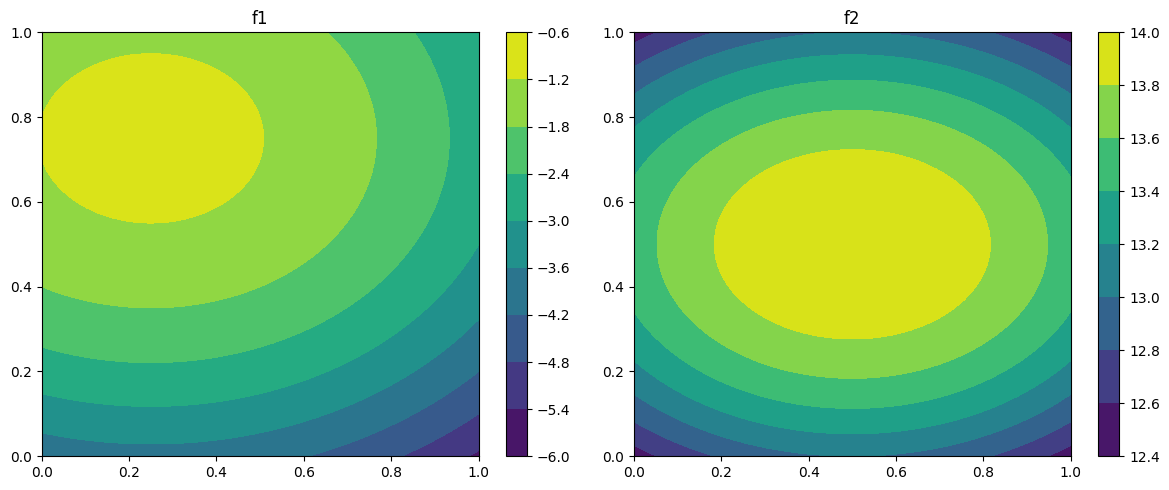

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cs1 = ax1.contourf(X1, X2, F1)
cs2 = ax2.contourf(X1, X2, F2)
fig.colorbar(cs1, ax=ax1)
fig.colorbar(cs2, ax=ax2)
ax1.set_title("f1")
ax2.set_title("f2")
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

initial_designs = torch.tensor([[0.25, 0.25], [0.75, 0.75], [0.375, 0.5], [0.125, 0.875]])
f1_values = torch.tensor([f1(x) for x in initial_designs])
f2_values = torch.tensor([f2(x) for x in initial_designs])
df = pd.DataFrame(initial_designs, columns=['x1', 'x2'])
df['f1'] = f1_values
df['f2'] = f2_values
df

,x1,x2,f1,f2
0,0.250,0.250,-2.250000,13.62500
1,0.750,0.750,-1.750000,13.62500
2,0.375,0.500,-1.359375,13.96875
3,0.125,0.875,-1.125000,13.15625


In [8]:
model1 = GaussianProcess(initial_designs, f1_values, squared_exponential_kernel)
mu1, cov1 = model1(X)

model2 = GaussianProcess(initial_designs, f2_values, squared_exponential_kernel)
mu2, cov2 = model2(X)

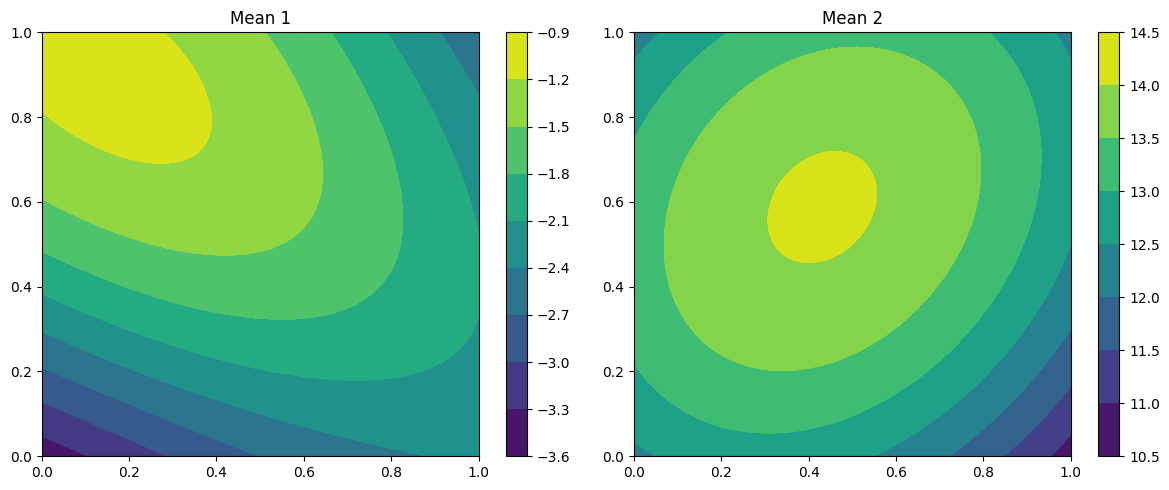

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cs1 = ax1.contourf(X1, X2, mu1.detach().reshape(X1.shape))
cs2 = ax2.contourf(X1, X2, mu2.detach().reshape(X1.shape))
fig.colorbar(cs1, ax=ax1)
fig.colorbar(cs2, ax=ax2)
ax1.set_title("Mean 1")
ax2.set_title("Mean 2")
plt.tight_layout()
plt.show()